In [3]:
import pandas as pd

In [4]:
df_sales = pd.read_csv(r'C:\Proyectos\Proyecto_Ventas_Inteligente\data\data_final.csv', 
                 encoding='latin1', 
                 sep=';', 
                 engine='python', 
                 on_bad_lines='skip')

In [5]:
import pandas as pd

# Definimos la ruta
ruta = r'C:\Proyectos\Proyecto_Ventas_Inteligente\data\data_final.csv'

# Cargamos el DataFrame
df = pd.read_csv(ruta, encoding='latin1', on_bad_lines='skip')

# Verificamos que todo esté en orden
print(f"Dimensiones del dataset: {df.shape}")
print(df.head())

Dimensiones del dataset: (537113, 1)
  InvoiceNo;StockCode;Description;Quantity;InvoiceDate;UnitPrice;CustomerID;Country
0  536365;85123A;WHITE HANGING HEART T-LIGHT HOLD...                               
1  536365;71053;WHITE METAL LANTERN;6;12/01/2010 ...                               
2  536365;84406B;CREAM CUPID HEARTS COAT HANGER;8...                               
3  536365;84029G;KNITTED UNION FLAG HOT WATER BOT...                               
4  536365;84029E;RED WOOLLY HOTTIE WHITE HEART.;6...                               


In [6]:
# Consolidamos y guardamos en una variable llamada 'df' (o el nombre que prefieras)
# Ver tipos de datos y si hay valores nulos
print(df.info())

# Ver cuántos nulos hay por cada columna
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537113 entries, 0 to 537112
Data columns (total 1 columns):
 #   Column                                                                             Non-Null Count   Dtype 
---  ------                                                                             --------------   ----- 
 0   InvoiceNo;StockCode;Description;Quantity;InvoiceDate;UnitPrice;CustomerID;Country  537113 non-null  object
dtypes: object(1)
memory usage: 4.1+ MB
None
InvoiceNo;StockCode;Description;Quantity;InvoiceDate;UnitPrice;CustomerID;Country    0
dtype: int64


In [7]:
import pandas as pd

# 1. Ruta del archivo
ruta = r'C:\Proyectos\Proyecto_Ventas_Inteligente\data\data_final.csv'

try:
    # 2. CARGA: Añadimos sep=';' para que Pandas entienda las columnas
    df = pd.read_csv(ruta, sep=';', encoding='latin1', on_bad_lines='skip')
    
    # 3. NORMALIZACIÓN: Limpiamos nombres de columnas (quitar espacios y minúsculas)
    df.columns = df.columns.str.strip().str.lower()
    
    print(f"Columnas detectadas correctamente: {df.columns.tolist()}")
    print(f"Total de registros cargados: {df.shape[0]}")

    # 4. LIMPIEZA DE DATOS
    # Ahora 'description' sí existe como columna independiente
    if 'description' in df.columns:
        df['description'] = df['description'].fillna('Sin descripción')
        print("Nulos en 'description' corregidos.")

    # Convertir fecha
    if 'invoicedate' in df.columns:
        df['invoicedate'] = pd.to_datetime(df['invoicedate'])
        print("Columna 'invoicedate' convertida a formato fecha.")

    # 5. ELIMINAR DUPLICADOS
    df = df.drop_duplicates()
    
    # 6. RESULTADO FINAL
    print("\n--- PRIMERAS FILAS DEL DATASET ---")
    print(df.head())
    print("\n--- ANÁLISIS DE NULOS ---")
    print(df.isnull().sum())

except Exception as e:
    print(f"Error al procesar el archivo: {e}")

Columnas detectadas correctamente: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']
Total de registros cargados: 541909
Nulos en 'description' corregidos.
Columna 'invoicedate' convertida a formato fecha.

--- PRIMERAS FILAS DEL DATASET ---
  invoiceno stockcode                          description  quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          invoicedate  unitprice  customerid         country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:

In [8]:
df_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,17850.0,United Kingdom


In [9]:
pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 1. Configuración de la nueva base de datos
server = 'LAPTOP-1NUBH4G6'
database = 'Proyecto_Ventas_Inteligente'  # <--- Cambiado aquí
driver = 'ODBC Driver 17 for SQL Server'

# 2. Cadena de conexión segura
params = urllib.parse.quote_plus(f'DRIVER={{{driver}}};SERVER={server};DATABASE={database};Trusted_Connection=yes')
conn_str = f"mssql+pyodbc:///?odbc_connect={params}"
engine = create_engine(conn_str)

# 3. Cargar el CSV procesado a SQL
# 'stg_sales' es un nombre estándar (staging) para datos recién cargados
try:
    df.to_sql('ventas_principales', con=engine, if_exists='replace', index=False)
    print(f"Los datos se subieron a la base de datos: {database}")
except Exception as e:
    print(f"Error al subir los datos: {e}")

Los datos se subieron a la base de datos: Proyecto_Ventas_Inteligente


In [11]:
df_ventas_principales = df

In [12]:
df_ventas_principales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    536641 non-null  object        
 1   stockcode    536641 non-null  object        
 2   description  536641 non-null  object        
 3   quantity     536641 non-null  int64         
 4   invoicedate  536641 non-null  datetime64[ns]
 5   unitprice    536641 non-null  float64       
 6   customerid   401604 non-null  float64       
 7   country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


In [13]:
df_ventas_principales.isnull().sum()

invoiceno           0
stockcode           0
description         0
quantity            0
invoicedate         0
unitprice           0
customerid     135037
country             0
dtype: int64

In [14]:
# 1. Manejo de CustomerID (Normalización)
# En lugar de dejar nulos, los convertimos a 0 (entero) para representar "Sin Registro"
df['customerid'] = df['customerid'].fillna(0).astype(int)

# 2. Segmentación de Devoluciones
# En este dataset, las cantidades negativas suelen ser cancelaciones o devoluciones.
# Creamos una columna nueva para no perder esa información, pero marcarla.
df['es_devolucion'] = df['quantity'] < 0

# 3. Limpieza de Precios y Cantidades
# Filtramos registros que no tienen sentido económico (ej. precio 0 o menor)
# Guardamos solo los registros con valor real para el análisis de ventas principal.
df_limpio = df[(df['unitprice'] > 0) & (df['quantity'] > 0)].copy()

# 4. Creación de métrica clave: TOTAL_VENTA
# Esta columna será la base de todos tus KPIs en SQL 
df_limpio['total_venta'] = df_limpio['quantity'] * df_limpio['unitprice']

# 5. Verificación final
print(f"Registros originales: {len(df)}")
print(f"Registros tras limpieza profunda: {len(df_limpio)}")
print(f"Monto total de ventas calculado: ${df_limpio['total_venta'].sum():,.2f}")

Registros originales: 536641
Registros tras limpieza profunda: 524878
Monto total de ventas calculado: $10,642,110.80


In [15]:
df_ventas_principales.info()


<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   invoiceno      536641 non-null  object        
 1   stockcode      536641 non-null  object        
 2   description    536641 non-null  object        
 3   quantity       536641 non-null  int64         
 4   invoicedate    536641 non-null  datetime64[ns]
 5   unitprice      536641 non-null  float64       
 6   customerid     536641 non-null  int32         
 7   country        536641 non-null  object        
 8   es_devolucion  536641 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 35.3+ MB


In [28]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 1. Configuración de la nueva base de datos
server = 'LAPTOP-1NUBH4G6'
database = 'Proyecto_Ventas_Inteligente'  # <--- Cambiado aquí
driver = 'ODBC Driver 17 for SQL Server'

# 2. Cadena de conexión segura
params = urllib.parse.quote_plus(f'DRIVER={{{driver}}};SERVER={server};DATABASE={database};Trusted_Connection=yes')
conn_str = f"mssql+pyodbc:///?odbc_connect={params}"
engine = create_engine(conn_str)

# 3. Cargar el CSV procesado a SQL
# 'stg_sales' es un nombre estándar (staging) para datos recién cargados
try:
    df.to_sql('ventas_principales_clean', con=engine, if_exists='replace', index=False)
    print(f"Los datos se subieron a la base de datos: {database}")
except Exception as e:
    print(f"Error al subir los datos: {e}")

Los datos se subieron a la base de datos: Proyecto_Ventas_Inteligente



VISUALIZACIÓN DE DATOS

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc

In [18]:
import pyodbc

conexion = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=LAPTOP-1NUBH4G6;'
    'DATABASE=Proyecto_Ventas_Inteligente;'
    'Trusted_Connection=yes;'
)

print("Conexión exitosa")

Conexión exitosa


C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\2052186744.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


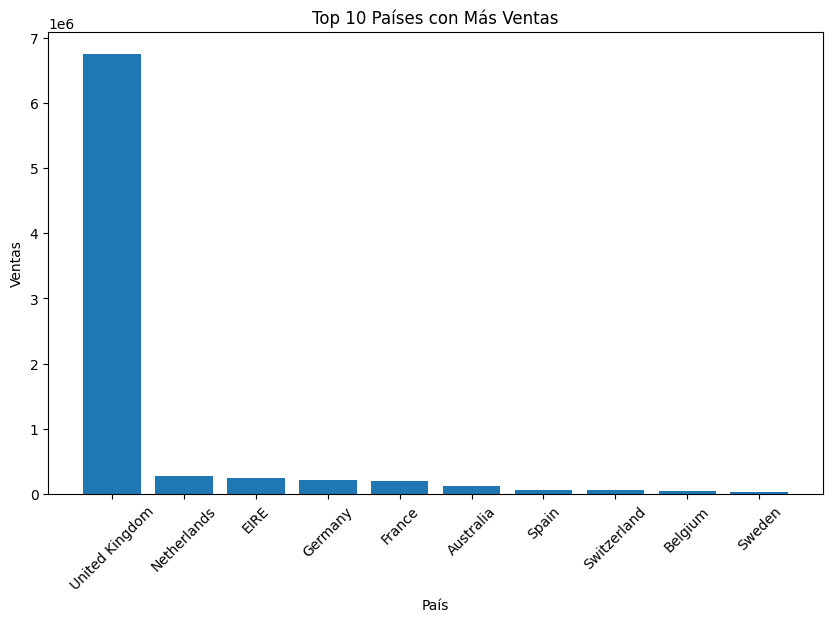

In [20]:
query = """
SELECT TOP 10
    c.country,
    SUM(v.totalamount) AS ventas
FROM ventas v
JOIN clientes c
    ON v.customerid = c.customerid
GROUP BY c.country
ORDER BY ventas DESC
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(10,6))
plt.bar(df['country'], df['ventas'])

plt.xticks(rotation=45)
plt.title('Top 10 Países con Más Ventas')
plt.xlabel('País')
plt.ylabel('Ventas')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\1348294045.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


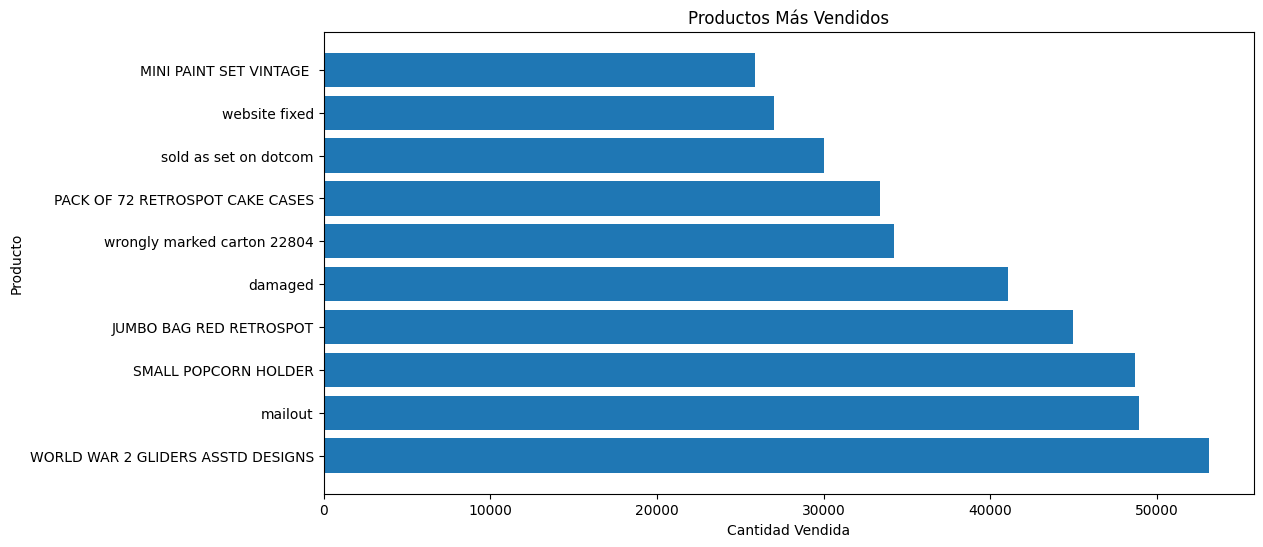

In [21]:
query = """
SELECT TOP 10
    p.description,
    SUM(dv.quantity) AS total_vendido
FROM detalle_ventas dv
JOIN productos p
    ON dv.stockcode = p.stockcode
WHERE p.description IS NOT NULL
AND p.description <> ''
AND p.description <> 'Sin descripción'
GROUP BY p.description
ORDER BY total_vendido DESC
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(12,6))
plt.barh(df['description'], df['total_vendido'])

plt.title('Productos Más Vendidos')
plt.xlabel('Cantidad Vendida')
plt.ylabel('Producto')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\2771863989.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


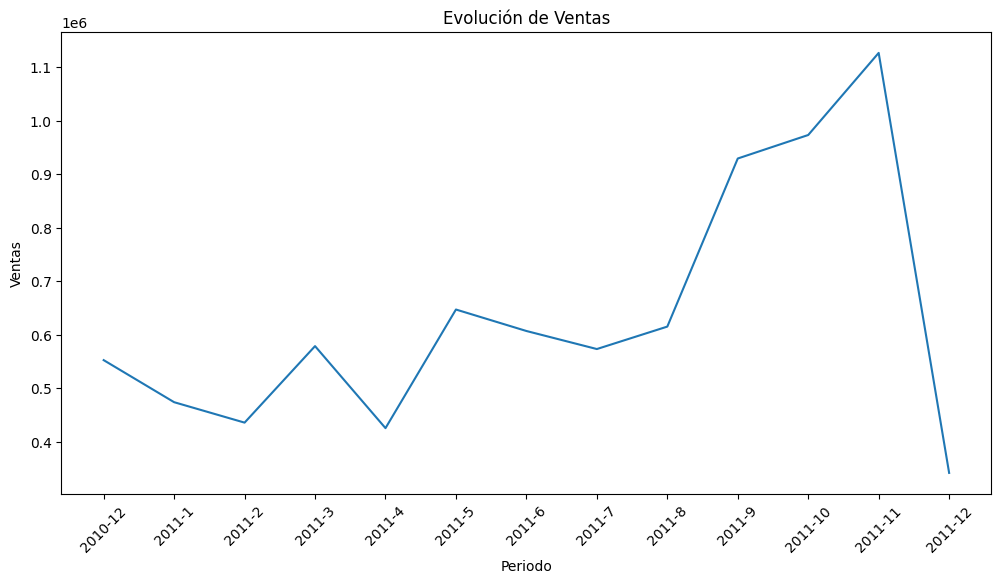

In [22]:
query = """
SELECT
    anio,
    mes,
    SUM(totalamount) AS ventas
FROM ventas
GROUP BY anio, mes
ORDER BY anio, mes
"""

df = pd.read_sql(query, conexion)

df['periodo'] = df['anio'].astype(str) + '-' + df['mes'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(df['periodo'], df['ventas'])

plt.xticks(rotation=45)
plt.title('Evolución de Ventas')
plt.xlabel('Periodo')
plt.ylabel('Ventas')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\3848567683.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


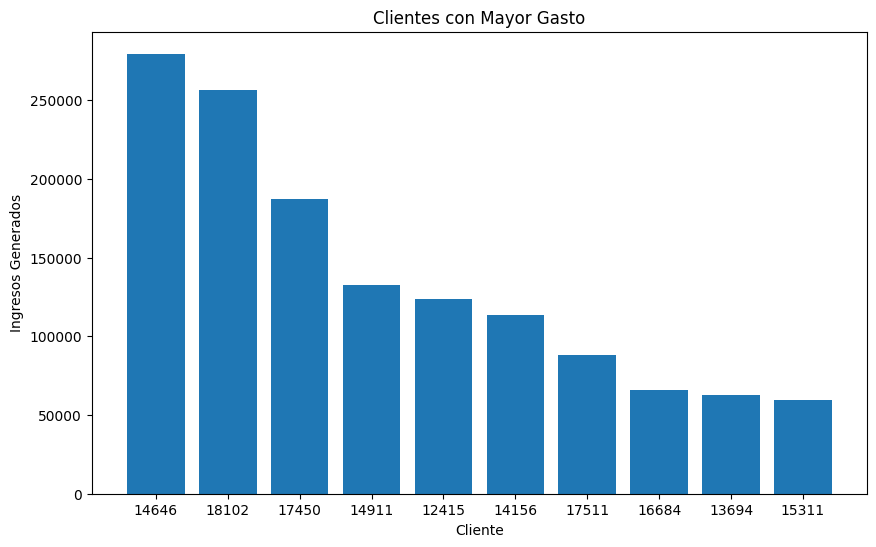

In [23]:
query = """
SELECT TOP 10
    customerid,
    SUM(totalamount) AS gasto_total
FROM ventas
GROUP BY customerid
ORDER BY gasto_total DESC
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(10,6))
plt.bar(df['customerid'].astype(str), df['gasto_total'])

plt.title('Clientes con Mayor Gasto')
plt.xlabel('Cliente')
plt.ylabel('Ingresos Generados')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\52238899.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


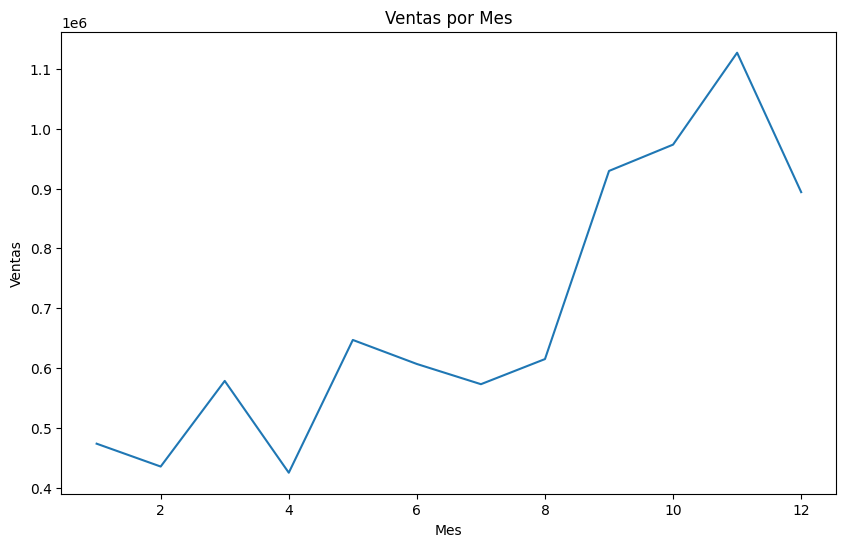

In [24]:
query = """
SELECT
    mes,
    SUM(totalamount) AS ventas
FROM ventas
GROUP BY mes
ORDER BY mes
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(10,6))
plt.plot(df['mes'], df['ventas'])

plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\1207263091.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


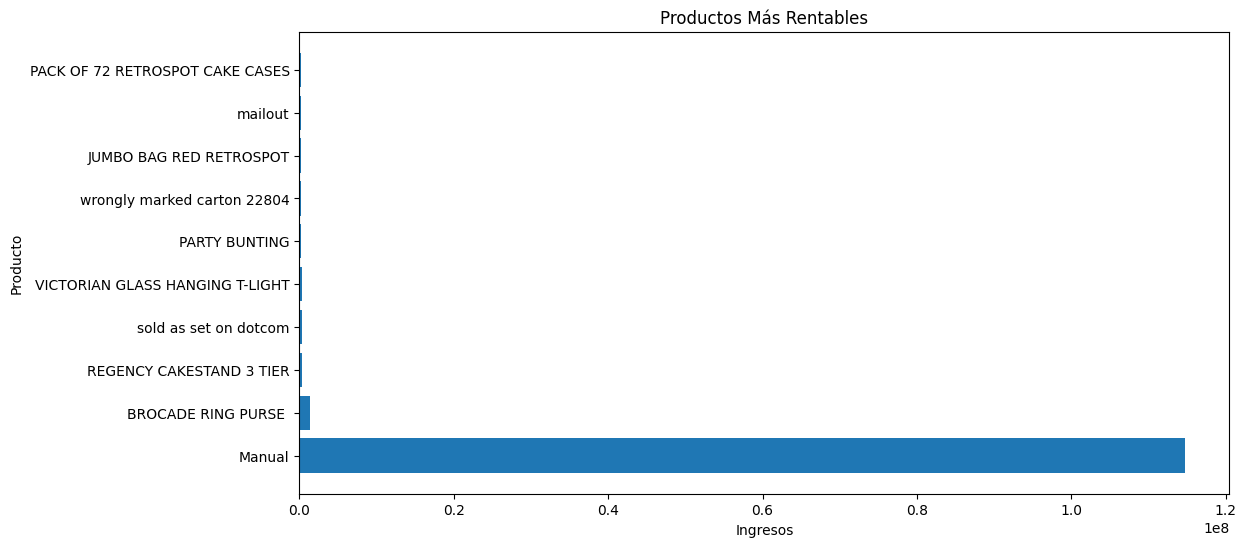

In [25]:
query = """
SELECT TOP 10
    p.description,
    SUM(dv.quantity * p.unitprice) AS ingresos
FROM detalle_ventas dv
JOIN productos p
    ON dv.stockcode = p.stockcode
WHERE p.description IS NOT NULL
AND p.description <> ''
AND p.description <> 'Sin descripción'
GROUP BY p.description
ORDER BY ingresos DESC
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(12,6))
plt.barh(df['description'], df['ingresos'])

plt.title('Productos Más Rentables')
plt.xlabel('Ingresos')
plt.ylabel('Producto')

plt.show()

C:\Users\RONY\AppData\Local\Temp\ipykernel_10608\3487290183.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


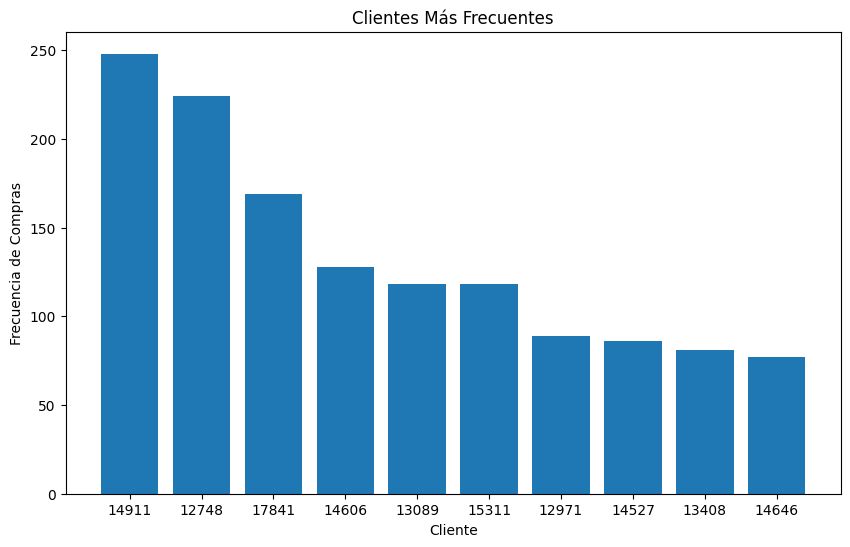

In [26]:
query = """
SELECT TOP 10
    customerid,
    COUNT(invoiceno) AS frecuencia
FROM ventas
GROUP BY customerid
ORDER BY frecuencia DESC
"""

df = pd.read_sql(query, conexion)

plt.figure(figsize=(10,6))
plt.bar(df['customerid'].astype(str), df['frecuencia'])

plt.title('Clientes Más Frecuentes')
plt.xlabel('Cliente')
plt.ylabel('Frecuencia de Compras')

plt.show()